# Projet intégré — Résolution approchée d'une EDP par PINN
## Version complète (pédagogique)

Ce notebook reprend les deux approches du projet (différences finies + PINN) et
comble les lacunes identifiées :

1. **Solution analytique** comme référence (existe pour la chaleur avec CI sinusoïdale)
2. **Étude de stabilité CFL** du schéma explicite (r = αΔt/Δx²)
3. **Comparaison quantitative** FDM ↔ PINN ↔ solution exacte (erreur L²)
4. **Problème inverse** : retrouver le coefficient α à partir de données bruitées
5. **Extension Burgers** (EDP non-linéaire — benchmark canonique des PINN)

### Références
- [1] Raissi, Perdikaris, Karniadakis (2019). *Physics-informed neural networks.* J. Comput. Phys.
- [2] Lu, Meng, Mao, Karniadakis (2021). *DeepXDE: A deep learning library for solving differential equations.* SIAM Review.
- [3] Karniadakis et al. (2021). *Physics-informed machine learning.* Nature Reviews Physics.

## §0 — Imports et configuration

In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"   # à définir AVANT l'import deepxde

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"[INFO] Résultats → {OUT_DIR}")

[INFO] Résultats → results


## §1 — Problème modèle : équation de la chaleur 1D

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad x \in [0, L], \quad t \in [0, T]$$

avec :
- **Conditions aux limites** (Dirichlet) : $u(0, t) = u(L, t) = 0$
- **Condition initiale** : $u(x, 0) = \sin(\pi x / L)$

### Solution analytique
Pour $L = 1$, la séparation de variables donne :
$$u_\text{exact}(x, t) = \sin(\pi x) \, e^{-\alpha \pi^2 t}$$

C'est cette solution qui servira de **référence absolue** pour valider FDM et PINN.

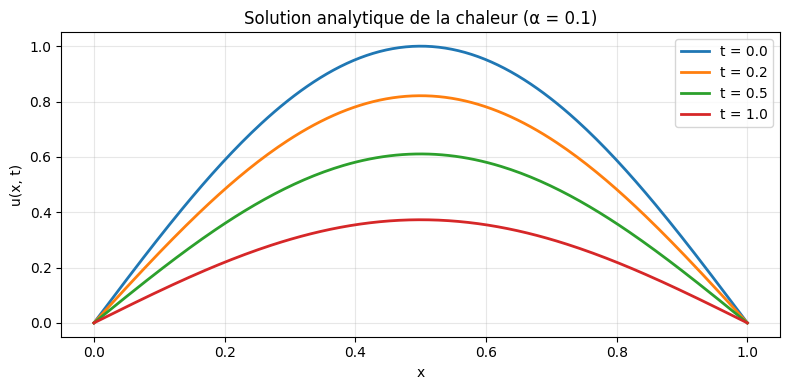

In [ ]:
# Paramètres physiques
L       = 1.0     # longueur de la barre
T_FINAL = 1.0     # durée de simulation
ALPHA   = 0.1     # coefficient de diffusion

def u_exact(x, t):
    """Solution analytique de l'équation de la chaleur avec CI sin(πx)."""
    return np.sin(np.pi * x) * np.exp(-ALPHA * np.pi**2 * t)

# Aperçu : profil exact à quelques instants
x_plot = np.linspace(0, L, 200)
fig, ax = plt.subplots(figsize=(8, 4))
for t in [0.0, 0.2, 0.5, 1.0]:
    ax.plot(x_plot, u_exact(x_plot, t), lw=2, label=f"t = {t:.1f}")
ax.set_xlabel("x"); ax.set_ylabel("u(x, t)")
ax.set_title("Solution analytique de la chaleur (α = 0.1)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig0_solution_exacte.png"), dpi=140)
plt.show()

## §2 — Méthode des différences finies (schéma explicite)

**Discrétisation** :
- $u_i^n \approx u(x_i, t_n)$ avec $x_i = i \Delta x$, $t_n = n \Delta t$
- Schéma explicite d'Euler en temps + différences centrées en espace :

$$u_i^{n+1} = u_i^n + r \, (u_{i+1}^n - 2 u_i^n + u_{i-1}^n), \quad r = \alpha \frac{\Delta t}{\Delta x^2}$$

**Condition de stabilité (CFL)** : $r \leq 1/2$, sinon le schéma diverge.

In [ ]:
def solve_fdm(nx, nt, L, T, alpha, ic_func):
    """Résolution de l'équation de la chaleur 1D par différences finies explicites."""
    dx = L / (nx - 1)
    dt = T / (nt - 1)
    r  = alpha * dt / dx**2

    x = np.linspace(0, L, nx)
    u = np.zeros((nt, nx))
    u[0, :] = ic_func(x)
    # CL Dirichlet : déjà 0 (tableau initialisé à zéro)

    for n in range(nt - 1):
        u[n+1, 1:-1] = u[n, 1:-1] + r * (u[n, 2:] - 2*u[n, 1:-1] + u[n, :-2])

    return x, np.linspace(0, T, nt), u, r

### §2.1 — Étude de la stabilité CFL
On compare un cas stable (r < 0.5) et un cas instable (r > 0.5).

In [ ]:
# Cas STABLE : r = 0.4
x_s, t_s, u_s, r_s = solve_fdm(nx=51, nt=2001, L=L, T=T_FINAL, alpha=ALPHA,
                                 ic_func=lambda x: np.sin(np.pi * x))
# Cas INSTABLE : r > 0.5 (on réduit le nombre de pas en temps)
x_u, t_u, u_u, r_u = solve_fdm(nx=51, nt=200,  L=L, T=T_FINAL, alpha=ALPHA,
                                 ic_func=lambda x: np.sin(np.pi * x))

print(f"Cas stable   : r = {r_s:.3f}  ({'OK' if r_s <= 0.5 else 'NON'})")
print(f"Cas instable : r = {r_u:.3f}  ({'OK' if r_u <= 0.5 else 'NON — divergence'})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_s, u_s[0], 'k-', label='t=0')
axes[0].plot(x_s, u_s[len(t_s)//4], label=f't={t_s[len(t_s)//4]:.2f}')
axes[0].plot(x_s, u_s[-1], label=f't={t_s[-1]:.2f}')
axes[0].set_title(f'Stable — r = {r_s:.3f}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x_u, u_u[0], 'k-', label='t=0')
axes[1].plot(x_u, u_u[len(t_u)//4], label=f't={t_u[len(t_u)//4]:.2f}')
axes[1].plot(x_u, u_u[-1], label=f't={t_u[-1]:.2f}')
axes[1].set_title(f'INSTABLE — r = {r_u:.3f} (oscillations / divergence)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('§2.1 — Condition CFL : r ≤ 1/2', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig1_cfl.png'), dpi=140)
plt.show()

Cas stable   : r = 0.125  (OK)
Cas instable : r = 1.256  (NON — divergence)


### §2.2 — Validation FDM contre la solution exacte
On calcule l'erreur L² sur tout le domaine.

Erreur L² relative FDM vs analytique : 3.526e-05


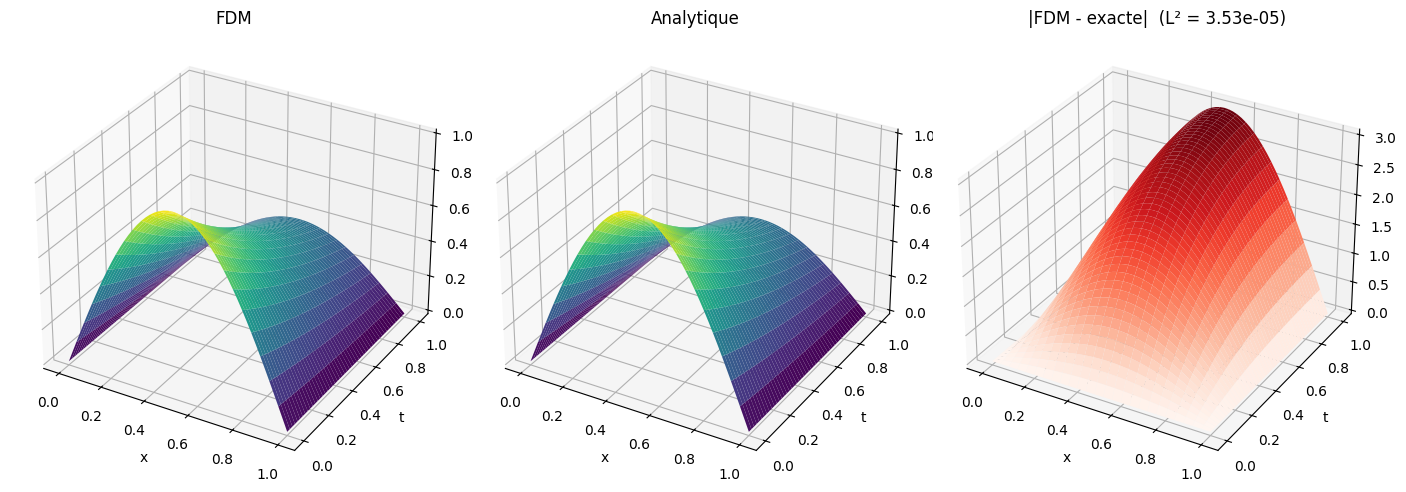

In [ ]:
# Solution exacte sur la même grille
X_s, T_s = np.meshgrid(x_s, t_s, indexing='xy')
u_ref    = u_exact(X_s, T_s)

def rel_L2(pred, ref):
    return np.linalg.norm(pred - ref) / np.linalg.norm(ref)

err_fdm = rel_L2(u_s, u_ref)
print(f"Erreur L² relative FDM vs analytique : {err_fdm:.3e}")

# Visualisation 3D : FDM vs exacte
fig = plt.figure(figsize=(14, 5))
X, Tm = np.meshgrid(x_s, t_s)

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Tm, u_s, cmap='viridis')
ax1.set_title('FDM'); ax1.set_xlabel('x'); ax1.set_ylabel('t'); ax1.set_zlabel('u')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Tm, u_ref, cmap='viridis')
ax2.set_title('Analytique'); ax2.set_xlabel('x'); ax2.set_ylabel('t'); ax2.set_zlabel('u')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X, Tm, np.abs(u_s - u_ref), cmap='Reds')
ax3.set_title(f'|FDM - exacte|  (L² = {err_fdm:.2e})')
ax3.set_xlabel('x'); ax3.set_ylabel('t'); ax3.set_zlabel('erreur')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig2_fdm_vs_exact.png'), dpi=140)
plt.show()

## §3 — Résolution par PINN (DeepXDE)

On entraîne un réseau de neurones $u_\theta(x, t)$ tel que la perte est :
$$\mathcal{L} = \mathcal{L}_\text{PDE} + \mathcal{L}_\text{BC} + \mathcal{L}_\text{IC}$$
où :
- $\mathcal{L}_\text{PDE} = \frac{1}{N_c} \sum |u_t - \alpha u_{xx}|^2$ sur les points de collocation
- $\mathcal{L}_\text{BC} = \sum |u_\theta(0,t)|^2 + |u_\theta(L,t)|^2$
- $\mathcal{L}_\text{IC} = \sum |u_\theta(x,0) - \sin(\pi x)|^2$

Les dérivées $u_t, u_{xx}$ sont calculées par **différentiation automatique**.

In [ ]:
# Installation si besoin (commenté par défaut)
!pip install --quiet deepxde

import deepxde as dde
import torch

torch.manual_seed(42)
print(f"DeepXDE version : {dde.__version__}")
print(f"Backend         : {dde.backend.backend_name}")

In [ ]:
# Géométrie : x ∈ [0, L] × t ∈ [0, T]
geom      = dde.geometry.Interval(0, L)
timedom   = dde.geometry.TimeDomain(0, T_FINAL)
geomtime  = dde.geometry.GeometryXTime(geom, timedom)

# EDP : u_t - α u_xx = 0
def pde_heat(x, u):
    """Résidu de l'équation de la chaleur. x = (x, t), u = u_θ(x, t)."""
    du_t  = dde.grad.jacobian(u, x, i=0, j=1)
    du_xx = dde.grad.hessian (u, x, i=0, j=0)
    return du_t - ALPHA * du_xx

# Conditions aux limites Dirichlet : u(0, t) = u(L, t) = 0
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)

# Condition initiale : u(x, 0) = sin(π x)
def ic_func(x):
    return np.sin(np.pi * x[:, 0:1])

ic = dde.icbc.IC(geomtime, ic_func, lambda _, on_initial: on_initial)

# Données : tirage des points de collocation
data = dde.data.TimePDE(
    geomtime, pde_heat, [bc, ic],
    num_domain   = 2000,
    num_boundary = 100,
    num_initial  = 200,
)

In [ ]:
# Réseau : 2 entrées (x, t) → 4 couches de 32 → 1 sortie
net   = dde.nn.FNN([2] + [32]*4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

# Phase 1 : Adam — exploration globale
model.compile("adam", lr=1e-3)
losshistory, train_state = model.train(iterations=5000, display_every=1000)

# Phase 2 : L-BFGS — raffinement local (deuxième ordre)
model.compile("L-BFGS")
losshistory, train_state = model.train()

## §4 — Comparaison FDM ↔ PINN ↔ Analytique

Évaluation du PINN sur la même grille que FDM pour comparer.

In [ ]:
# Évaluation du PINN sur la grille FDM
X_grid, T_grid = np.meshgrid(x_s, t_s, indexing='xy')
xt_eval = np.vstack([X_grid.ravel(), T_grid.ravel()]).T
u_pinn  = model.predict(xt_eval).reshape(X_grid.shape)

err_pinn = rel_L2(u_pinn, u_ref)
print(f"Erreur L² relative  FDM   vs analytique : {err_fdm:.3e}")
print(f"Erreur L² relative  PINN  vs analytique : {err_pinn:.3e}")

In [ ]:
# Comparaison sur 4 instants
snapshots = [0.0, 0.2, 0.5, 1.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, t_snap in zip(axes, snapshots):
    idx = np.argmin(np.abs(t_s - t_snap))
    ax.plot(x_s, u_ref [idx], 'k-',  lw=2.5, label='Analytique')
    ax.plot(x_s, u_s   [idx], 'b--', lw=1.5, label='FDM')
    ax.plot(x_s, u_pinn[idx], 'r:',  lw=2.0, label='PINN')
    ax.set_title(f't = {t_snap}')
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('u(x, t)')
axes[0].legend()
plt.suptitle(f'§4 — Comparaison aux instants clés  (eᵣ FDM = {err_fdm:.2e}, eᵣ PINN = {err_pinn:.2e})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig3_fdm_pinn_exact.png'), dpi=140)
plt.show()

In [ ]:
# Vue 3D : analytique vs PINN vs erreur PINN
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_grid, T_grid, u_ref, cmap='viridis')
ax1.set_title('Analytique'); ax1.set_xlabel('x'); ax1.set_ylabel('t')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X_grid, T_grid, u_pinn, cmap='viridis')
ax2.set_title('PINN'); ax2.set_xlabel('x'); ax2.set_ylabel('t')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X_grid, T_grid, np.abs(u_pinn - u_ref), cmap='Reds')
ax3.set_title(f'|PINN - exacte|  (L² = {err_pinn:.2e})')
ax3.set_xlabel('x'); ax3.set_ylabel('t')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig4_pinn_3d.png'), dpi=140)
plt.show()

## §5 — Problème INVERSE : retrouver α à partir de données bruitées

**C'est là où les PINN brillent vraiment** (cf. PFA, point §6 du papier de Raissi).

Scénario : on a quelques mesures bruitées de $u(x, t)$ mais on **ignore** le coefficient $\alpha$.
Le PINN doit l'apprendre simultanément aux solutions.

→ Une méthode classique (FDM) ne sait pas faire ça sans optimisation externe coûteuse.

In [ ]:
# Génération de mesures bruitées (à partir de la solution analytique)
N_OBS = 100
x_obs = np.random.uniform(0, L,       (N_OBS, 1))
t_obs = np.random.uniform(0, T_FINAL, (N_OBS, 1))
u_obs = u_exact(x_obs, t_obs) + 0.01 * np.random.randn(N_OBS, 1)   # bruit 1%
X_obs = np.hstack([x_obs, t_obs])

# α devient un paramètre apprenable (initialisé loin de la vraie valeur)
alpha_var = dde.Variable(0.5)

def pde_inverse(x, u):
    du_t  = dde.grad.jacobian(u, x, i=0, j=1)
    du_xx = dde.grad.hessian (u, x, i=0, j=0)
    return du_t - alpha_var * du_xx

# Observations comme contrainte ponctuelle
obs_bc = dde.icbc.PointSetBC(X_obs, u_obs)

data_inv = dde.data.TimePDE(
    geomtime, pde_inverse,
    [bc, ic, obs_bc],
    num_domain   = 2000,
    num_boundary = 100,
    num_initial  = 200,
    anchors      = X_obs,
)

net_inv   = dde.nn.FNN([2] + [32]*4 + [1], "tanh", "Glorot normal")
model_inv = dde.Model(data_inv, net_inv)

# Callback pour suivre α au fil de l'entraînement
alpha_history = []
class TrackAlpha(dde.callbacks.Callback):
    def on_epoch_end(self):
        alpha_history.append(float(alpha_var.detach().cpu().numpy()))

model_inv.compile("adam", lr=1e-3, external_trainable_variables=[alpha_var])
model_inv.train(iterations=8000, display_every=2000, callbacks=[TrackAlpha()])
model_inv.compile("L-BFGS", external_trainable_variables=[alpha_var])
model_inv.train(callbacks=[TrackAlpha()])

alpha_final = float(alpha_var.detach().cpu().numpy())
print(f"\nα vrai     : {ALPHA}")
print(f"α initial  : 0.5")
print(f"α appris   : {alpha_final:.5f}")
print(f"Erreur rel : {abs(alpha_final - ALPHA) / ALPHA * 100:.2f} %")

In [ ]:
# Convergence de α au fil des époques
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alpha_history, lw=1.5, label='α appris')
ax.axhline(ALPHA, color='k', ls='--', label=f'α vrai = {ALPHA}')
ax.axhline(0.5,   color='r', ls=':',  alpha=0.5, label='α initial = 0.5')
ax.set_xlabel('Itération')
ax.set_ylabel('α')
ax.set_title(f'§5 — Découverte du coefficient α (problème inverse)\n'
             f'Valeur finale : {alpha_final:.5f}  (vraie : {ALPHA})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig5_inverse_alpha.png'), dpi=140)
plt.show()

## §6 — Extension : équation de Burgers (non-linéaire)

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

C'est **le benchmark canonique** des PINN (Raissi et al. 2019). Difficile pour les schémas
classiques car le terme non-linéaire $u u_x$ crée un **choc** quand $\nu$ est petit.

**Paramètres** :
- $x \in [-1, 1]$, $t \in [0, 1]$
- $\nu = 0.01 / \pi$
- CI : $u(x, 0) = -\sin(\pi x)$
- CL : $u(\pm 1, t) = 0$

In [ ]:
NU = 0.01 / np.pi

geom_b      = dde.geometry.Interval(-1, 1)
tdom_b      = dde.geometry.TimeDomain(0, 1)
geomtime_b  = dde.geometry.GeometryXTime(geom_b, tdom_b)

def pde_burgers(x, u):
    du_x  = dde.grad.jacobian(u, x, i=0, j=0)
    du_t  = dde.grad.jacobian(u, x, i=0, j=1)
    du_xx = dde.grad.hessian (u, x, i=0, j=0)
    return du_t + u * du_x - NU * du_xx

bc_b = dde.icbc.DirichletBC(geomtime_b, lambda x: 0, lambda _, on_b: on_b)
ic_b = dde.icbc.IC(geomtime_b, lambda x: -np.sin(np.pi * x[:, 0:1]),
                    lambda _, on_init: on_init)

data_b = dde.data.TimePDE(
    geomtime_b, pde_burgers, [bc_b, ic_b],
    num_domain=2500, num_boundary=80, num_initial=160,
)

net_b   = dde.nn.FNN([2] + [40]*5 + [1], "tanh", "Glorot normal")
model_b = dde.Model(data_b, net_b)

model_b.compile("adam", lr=1e-3)
model_b.train(iterations=8000, display_every=2000)
model_b.compile("L-BFGS"); model_b.train()

In [ ]:
# Visualisation Burgers — formation du choc
x_b = np.linspace(-1, 1, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for t_b in [0.0, 0.25, 0.5, 0.75, 1.0]:
    xt = np.vstack([x_b, np.full_like(x_b, t_b)]).T
    u_b = model_b.predict(xt)
    ax.plot(x_b, u_b, lw=2, label=f't = {t_b}')
ax.set_xlabel('x'); ax.set_ylabel('u(x, t)')
ax.set_title('Burgers — profils u(x, t)\n(le choc se forme près de x = 0)')
ax.legend(); ax.grid(alpha=0.3)

# Heatmap
Nx_b, Nt_b = 200, 100
x_g = np.linspace(-1, 1, Nx_b)
t_g = np.linspace(0, 1, Nt_b)
X_b, T_b = np.meshgrid(x_g, t_g)
xt_b = np.vstack([X_b.ravel(), T_b.ravel()]).T
U_b  = model_b.predict(xt_b).reshape(X_b.shape)

ax = axes[1]
im = ax.imshow(U_b, extent=[-1, 1, 0, 1], origin='lower',
               aspect='auto', cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='u')
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title('Burgers — solution u(x, t) prédite par PINN')

plt.suptitle('§6 — Équation de Burgers (non-linéaire, ν = 0.01/π)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig6_burgers.png'), dpi=140)
plt.show()

## Synthèse

| Méthode  | Direct (chaleur) | Inverse (α inconnu) | Non-linéaire (Burgers) |
|----------|:---:|:---:|:---:|
| FDM      | ✅ rapide, précis | ❌ nécessite optimisation externe | ⚠️ chocs difficiles |
| PINN     | ✅ sans maillage | ✅ naturel | ✅ benchmark canonique |

**Toutes les figures sont dans `results/`.**